# Was Norway really a 2026 World Cup underdog?
### A pre-tournament forecast and a retrospective test

**Research question.** Did Norway's results before the 2026 World Cup suggest a stronger team than its reputation implied, and did a contemporary title market already recognize that strength?

**Why the distinction matters.** “Underdog” may refer to reputation, the probability of winning one match, or the probability of winning a tournament. Those are different quantities. A surprising result does not establish that a forecast was poor; the relevant question is what probability was reasonable *before* the event. The same distinction applies to prediction markets and other uncertain events.

**Working definition.** A *recognized dark horse* is a team outside the leading title favorites that nevertheless shows strong pre-tournament performance and appears relatively high in an outright market ranking. This is a qualitative classification, not a statistical threshold or a claim that the market undervalued the team. Match strength and outright title odds are evaluated separately.

**Information rule.** Model inputs end before **June 10, 2026** (matches through June 9). World Cup scores are held out until the results section. The bundled snapshot includes later matches for evaluation, but a date filter and assertion exclude them from fitting. A June 11 sportsbook quote is a separate, dated comparison; its exact timing relative to the opening match is not established here, and it is never used to fit the model.

The notebook runs from top to bottom with the accompanying CSV in the same directory. Required packages: `pandas`, `numpy`, `scipy`, and `matplotlib`; `IPython` improves table display but is optional.

### Three concepts that must stay separate

A **forecast** assigns probabilities using information available before the event. A **probability** of 0.25 means 25% across comparable situations, not a promise that the outcome occurs exactly once in four cases. **Calibration** means that outcomes assigned a certain probability occur at approximately that frequency across *many* forecasts; six matches cannot establish it.

| Claim | Quantity needed | Role here |
|---|---|---|
| Norway was strong | Opponent-adjusted attack and defense estimates | Estimated from pre-tournament scores |
| Norway could win a given match | Win/draw/loss probabilities for that matchup | Estimated by the Poisson model |
| Norway could win the title | Probability of winning the complete tournament | Described by a dated market quote; not estimated by this model |

The sequence is historical results → adjusted scoring rates → matchup probabilities → separate market comparison → held-out outcomes. This order makes the information available at each stage explicit.

## 1. Set the information cutoff and inspect the evidence

The supplied CSV is a frozen, reduced snapshot of [Mart Jürisoo’s international results dataset](https://github.com/martj42/international_results), downloaded September 28, 2026 and limited to January 2024–July 11, 2026. Its columns include date, goals, competition, and neutral venue. It is a community compilation, not an official FIFA feed, so important results should be checked against [FIFA’s tournament record](https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/knockout-stage-match-schedule-bracket). Goals in the dataset can include extra time; the knockout rows are for the reveal, never training. The score model approximates one-match scoring and does not separately model extra time or shootouts.

**Reason for the window.** Starting in January 2024 gives more matches than a few qualifiers while emphasizing a relatively current team. That date is a transparent design choice, not an optimized cutoff. Older results receive less weight later. The tournament itself cannot train a pre-tournament forecast: doing so would use future information. This is **temporal leakage**.

In [3]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import poisson
try:
    from IPython.display import display
except ImportError:
    display = print

CUTOFF = pd.Timestamp('2026-06-10')
DATA = Path('international_results_2024_2026-07-11.csv')
if not DATA.exists():
    raise FileNotFoundError('Place the accompanying CSV next to this notebook.')
raw = pd.read_csv(DATA, parse_dates=['date'])
raw['home_score'] = pd.to_numeric(raw.home_score, errors='coerce')
raw['away_score'] = pd.to_numeric(raw.away_score, errors='coerce')
assert {'date','home_team','away_team','home_score','away_score','tournament','neutral'} <= set(raw)
pre = raw.loc[(raw.date >= '2024-01-01') & (raw.date < CUTOFF)].dropna(subset=['home_score','away_score']).copy()
assert pre.date.max() < CUTOFF
print(f'{len(pre):,} pre-cutoff matches; latest training match: {pre.date.max():%Y-%m-%d}')
print('Post-cutoff rows excluded from modeling:', (raw.date >= CUTOFF).sum())

2,548 pre-cutoff matches; latest training match: 2026-06-09
Post-cutoff rows excluded from modeling: 104


**Temporal check.** The file contains 104 rows on or after the cutoff, but the `pre` training table contains none. The held-out rows exist only to reveal outcomes after the forecast has been fixed. This separation is necessary for a meaningful retrospective forecast.

## 2. The first scouting signal: Norway’s record

A scoreline is evidence, but scoring four against a weak opponent is less informative than doing so against a strong one. The raw record is examined first; opponent strength is accounted for afterward.

FIFA’s [pre-tournament account](https://www.fifa.com/it/tournaments/mens/worldcup/canadamexicousa2026/articles/erling-haaland-statistiche-dichiarazioni-record) reports eight qualifying wins, 37 goals scored and five allowed. Verify whether this snapshot reproduces that summary. A mismatch should be investigated, not silently ignored.

Qualifying rows: 8  | W-D-L: {'W': 8}  | goals: 37 - 5


           date     opponent                    tournament  GF  GA result
831  2024-10-10     Slovenia           UEFA Nations League   3   0      W
913  2024-10-13      Austria           UEFA Nations League   1   5      L
1004 2024-11-14     Slovenia           UEFA Nations League   4   1      W
1093 2024-11-17   Kazakhstan           UEFA Nations League   5   0      W
1334 2025-03-22      Moldova  FIFA World Cup qualification   5   0      W
1427 2025-03-25       Israel  FIFA World Cup qualification   4   2      W
1498 2025-06-06        Italy  FIFA World Cup qualification   3   0      W
1543 2025-06-09      Estonia  FIFA World Cup qualification   1   0      W
1668 2025-09-04      Finland                      Friendly   1   0      W
1812 2025-09-09      Moldova  FIFA World Cup qualification  11   1      W
1909 2025-10-11       Israel  FIFA World Cup qualification   5   0      W
1955 2025-10-14  New Zealand                      Friendly   1   1      D
2021 2025-11-13      Estonia  FIFA Wor

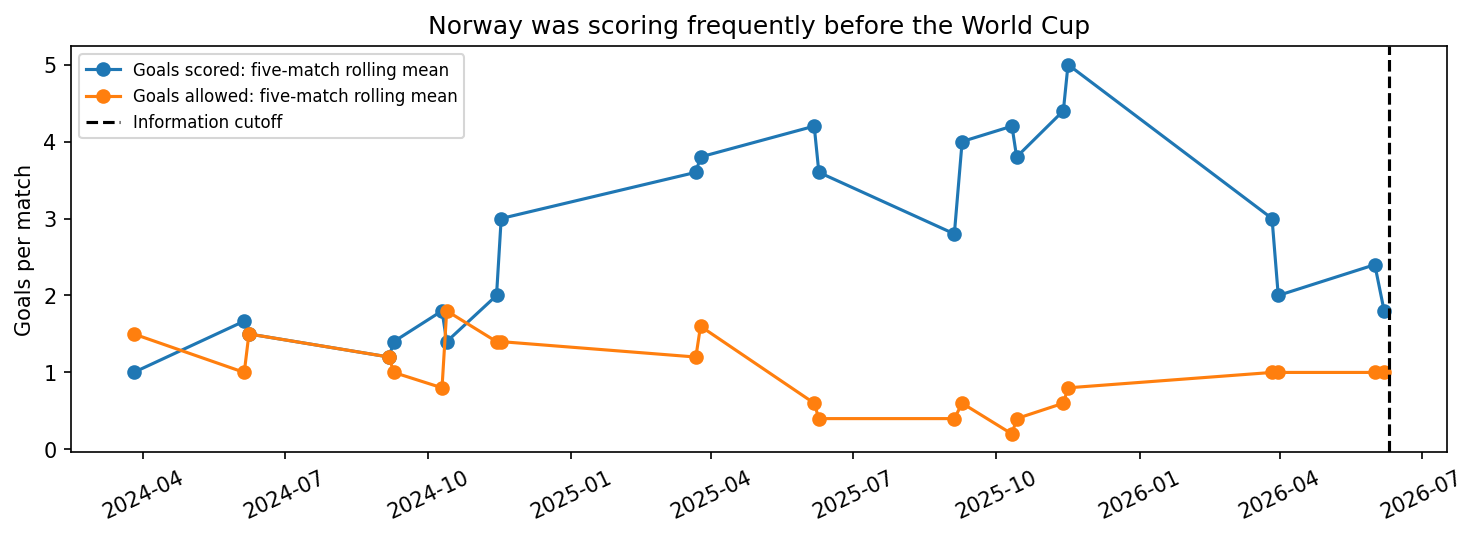

In [6]:
nor = pre[(pre.home_team.eq('Norway')) | (pre.away_team.eq('Norway'))].copy()
nor['opponent'] = np.where(nor.home_team.eq('Norway'), nor.away_team, nor.home_team)
nor['GF'] = np.where(nor.home_team.eq('Norway'), nor.home_score, nor.away_score).astype(int)
nor['GA'] = np.where(nor.home_team.eq('Norway'), nor.away_score, nor.home_score).astype(int)
nor['result'] = np.select([nor.GF>nor.GA, nor.GF==nor.GA], ['W','D'], default='L')
qual = nor[nor.tournament.str.contains('FIFA World Cup qualification', case=False, na=False)]
display(nor[['date','opponent','tournament','GF','GA','result']].sort_values('date').tail(18))
print('Qualifying rows:',len(qual),' | W-D-L:',qual.result.value_counts().to_dict(),
      ' | goals:',int(qual.GF.sum()),'-',int(qual.GA.sum()))
fig, ax=plt.subplots(figsize=(10,3.7))
t=nor.sort_values('date')
ax.plot(t.date,t.GF.rolling(5,min_periods=2).mean(),marker='o',label='Goals scored: five-match rolling mean')
ax.plot(t.date,t.GA.rolling(5,min_periods=2).mean(),marker='o',label='Goals allowed: five-match rolling mean')
ax.axvline(CUTOFF,color='black',ls='--',label='Information cutoff')
ax.set(ylabel='Goals per match',title='Norway was scoring frequently before the World Cup')
ax.legend(fontsize=8); plt.xticks(rotation=25); plt.tight_layout(); plt.show()

**Why show both the match list and a rolling average?** The eight qualifying wins and 37–5 goal total can be checked against FIFA's account. A five-match rolling average reduces the visual impact of one exceptional score, such as 11–1 against Moldova. Both views describe observed results; neither adjusts for opponent strength or forecasts a new match.

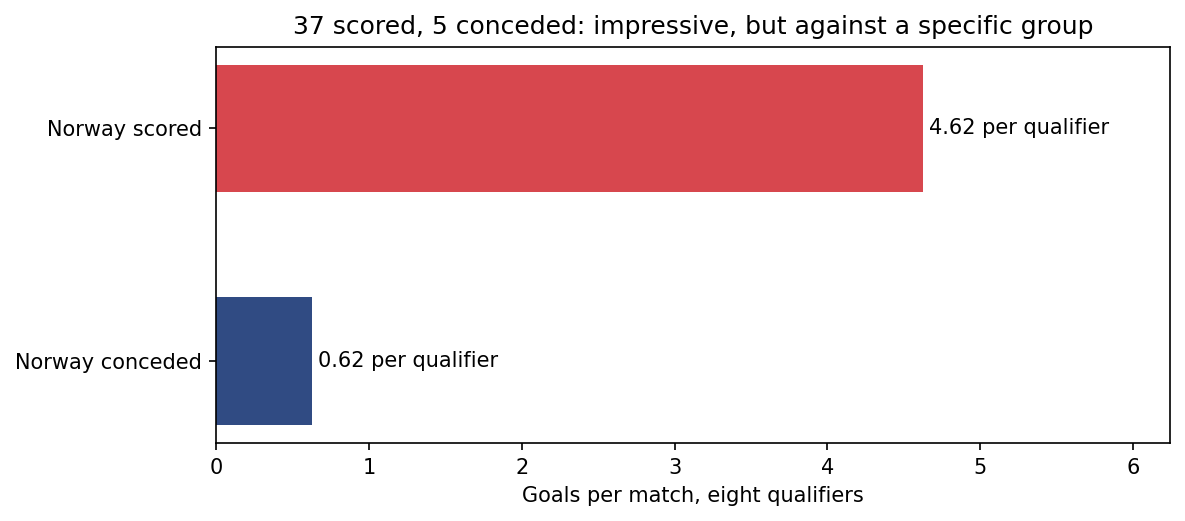

In [8]:
fig,ax=plt.subplots(figsize=(8,3.6))
labels=['Norway scored','Norway conceded']
values=[qual.GF.sum()/len(qual),qual.GA.sum()/len(qual)]
bars=ax.barh(labels,values,color=['#d7474e','#304b83'],height=.55)
for bar,v in zip(bars,values): ax.text(v+.04,bar.get_y()+bar.get_height()/2,f'{v:.2f} per qualifier',va='center')
ax.set_xlim(0,max(values)*1.35)
ax.set(xlabel='Goals per match, eight qualifiers',title='37 scored, 5 conceded: impressive, but against a specific group')
ax.invert_yaxis();plt.tight_layout();plt.show()

**What the raw record cannot establish.** A perfect qualifying run is a genuine signal, but the difficulty of opponents varies. The next model uses all pre-cutoff international matches in the snapshot to estimate scoring and conceding relative to opponents.

## 3. Estimate attack and defense

The course lecture treats a new fixture's scoring rate as a combination of one side's attack and the other's defense. Two dimensionless indices approximate those components:

- **Attack index:** the ratio of scoring relative to an average team after adjusting for the opponent's defense. Higher than 1 means stronger scoring in this model.
- **Defense index:** the ratio of goals allowed relative to an average team after adjusting for the opponent's attack. Lower than 1 means fewer goals allowed in this model.

**Why these choices?** Separate attack and defense allow the same country to face different expected-goals rates against different opponents. Recent games receive more weight because squads and form change. A 365-day **half-life** means a game one year old has half the weight of a new game. Friendlies receive 50% of a competitive game's weight because their incentives and lineups may differ. Neither weight is estimated from validation data; both are exposed in sensitivity checks.

Six average-strength **pseudo-matches** shrink extreme rates toward 1 for teams with few observations. They are prior weight in a formula, not fabricated real fixtures. Six is a transparent stabilizing choice rather than an optimized value; varying it is an unperformed robustness check. The implementation iteratively adjusts attack and defense for opponents. It is a *rate-proxy*, not a fitted Dixon–Coles or maximum-likelihood regression. No home advantage is estimated, so forecast fixtures are treated as neutral.

### From goals to an index: a small example

If the average team scores 1.4 goals per match against an average defense and a team scores 2.8 in equally difficult matches, its attack index would be `2.8 ÷ 1.4 = 2.0`. If a defense concedes 0.7 where an average defense would concede 1.4, its index would be `0.7 ÷ 1.4 = 0.5`. **Lower is better for defense.**

Actual opponents are unequal. All teams start at index 1. Attack estimates are updated against their opponents' current defense estimates; defense estimates are then updated against current attack estimates. Repeating that adjustment 30 times produces stable rate proxies for this snapshot. The pseudo-match prior contributes average-strength goals to both sides of the rate calculation, so sparse teams remain closer to 1.

**Scope of the estimate.** The global average and the indices come from the mixed schedule of 239 teams in the selected period. Cross-confederation comparisons can be weak when teams rarely play each other. The plotted indices therefore describe this model, not an official rating.

In [11]:
fit = pre.copy()
fit['age_days'] = (CUTOFF - fit.date).dt.days
fit['weight'] = 0.5 ** (fit.age_days / 365)
fit.loc[fit.tournament.eq('Friendly'),'weight'] *= 0.5
# Avoid selection by eventual knockout opponent: estimate every team using all available pre-cutoff games.
teams = sorted(set(fit.home_team) | set(fit.away_team))
h = fit.home_team.map({x:i for i,x in enumerate(teams)}).to_numpy()
a = fit.away_team.map({x:i for i,x in enumerate(teams)}).to_numpy()
w = fit.weight.to_numpy()
gh = fit.home_score.to_numpy(float); ga = fit.away_score.to_numpy(float)
base = np.average(np.r_[gh,ga], weights=np.r_[w,w])
print('Weighted global goals per team per match:',round(base,3),' | teams:',len(teams))

def estimate(half_life=365, friendly_weight=0.5, prior_games=6, iterations=30):
    weights = 0.5 ** (fit.age_days.to_numpy()/half_life)
    weights = weights * np.where(fit.tournament.eq('Friendly'),friendly_weight,1.0)
    mu = np.average(np.r_[gh,ga],weights=np.r_[weights,weights])
    played = np.bincount(np.r_[h,a],weights=np.r_[weights,weights],minlength=len(teams))
    attack = np.ones(len(teams)); defense = np.ones(len(teams))
    for _ in range(iterations):
        scored = np.bincount(np.r_[h,a],weights=np.r_[weights*gh,weights*ga],minlength=len(teams))
        expected_scored = np.bincount(np.r_[h,a],weights=np.r_[weights*mu*defense[a],weights*mu*defense[h]],minlength=len(teams))
        new_attack = (scored + prior_games*mu)/(expected_scored + prior_games*mu)
        allowed = np.bincount(np.r_[h,a],weights=np.r_[weights*ga,weights*gh],minlength=len(teams))
        expected_allowed = np.bincount(np.r_[h,a],weights=np.r_[weights*mu*new_attack[a],weights*mu*new_attack[h]],minlength=len(teams))
        new_defense = (allowed + prior_games*mu)/(expected_allowed + prior_games*mu)
        attack,defense = new_attack,new_defense
    return pd.DataFrame({'team':teams,'attack':attack,'defense':defense,'weighted_matches':played}).set_index('team'),mu
strength, mu = estimate()
display(strength.loc[['Norway','France','Senegal','Iraq','Brazil','England']].round(2))
assert strength.loc[['Norway','France','Senegal','Iraq','Brazil','England'],'weighted_matches'].min()>0

Weighted global goals per team per match: 1.409  | teams: 239


         attack  defense  weighted_matches
team                                      
Norway     1.80     0.71              9.27
France     1.40     0.68             11.43
Senegal    1.53     0.60             15.02
Iraq       0.97     0.69             15.61
Brazil     1.42     0.74              9.93
England    1.42     0.56             10.64

**How to interpret the output.** Norway's attack near 1.80 represents about 80% more goals than this model's average reference against an average defense. Its defense near 0.71 represents about 29% fewer goals allowed against an average attack. “Weighted matches” is the total evidence after time and friendly discounts, not the count of distinct fixtures. The diagram places selected opponents on the same two-index scale; it is not a title forecast.

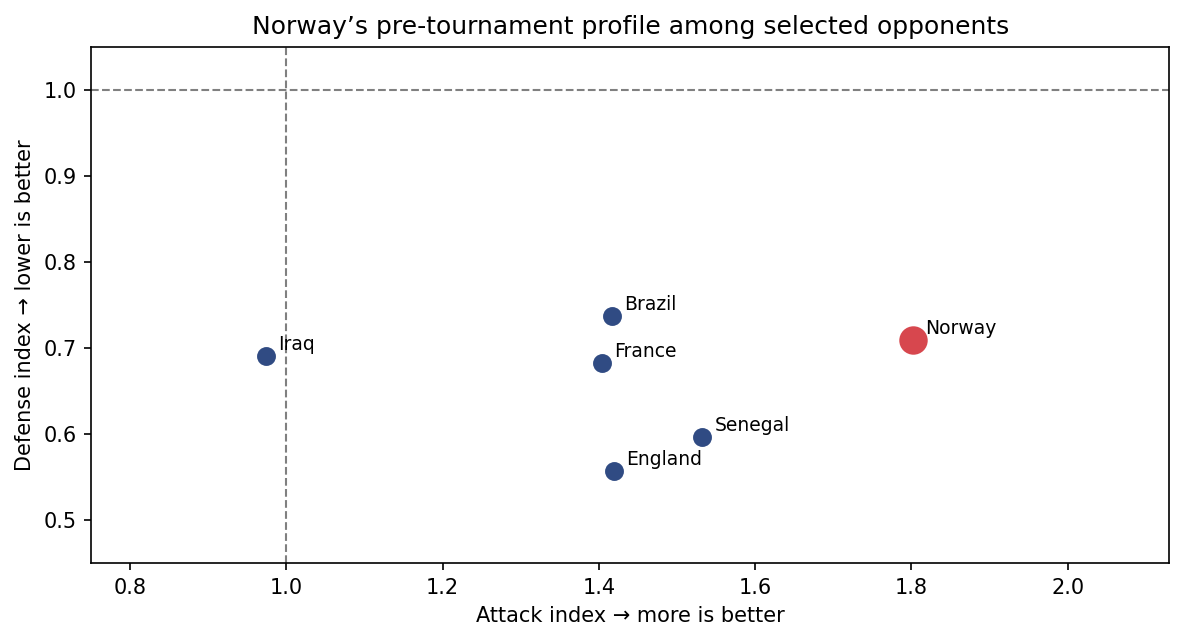

In [13]:
key=['Norway','France','Senegal','Iraq','Brazil','England']
view=strength.loc[key].copy().sort_values('attack')
fig,ax=plt.subplots(figsize=(8,4.4))
for team,row in view.iterrows():
 ax.scatter(row['attack'],row['defense'],s=160 if team=='Norway' else 65,
            c='#d7474e' if team=='Norway' else '#304b83',zorder=3)
 ax.annotate(team,(row['attack'],row['defense']),xytext=(6,3),textcoords='offset points',fontsize=9)
ax.axvline(1,color='gray',ls='--',lw=1);ax.axhline(1,color='gray',ls='--',lw=1)
ax.set(xlabel='Attack index → more is better',ylabel='Defense index → lower is better',
       title='Norway’s pre-tournament profile among selected opponents')
ax.set_xlim(.75,2.13);ax.set_ylim(.45,1.05);plt.tight_layout();plt.show()

**Interpretation of the scale.** An attack index of 1.5 corresponds to roughly 50% more expected goals than the model average against an average defense. A defense index of 0.8 corresponds to roughly 20% fewer expected goals allowed. These are estimates from observed goals, not shot-quality xG.

## 4. Convert strengths into a match forecast

For a neutral Norway–B fixture, `λ_N = average goals × Norway attack × B defense` and `λ_B = average goals × B attack × Norway defense`. **λ (lambda)** is the *expected number of goals* in one matchup, not an exact score prediction. Separate λ values are necessary because the teams have different attacks and face different defenses.

A **Poisson distribution** turns each λ into probabilities of scoring 0, 1, 2, and so on. Assuming the two goal totals are independent, multiplying the probabilities of each score pair gives a score matrix. Cells where Norway scores more are Norway wins; equal scores are draws. This is a tractable baseline, although shared match conditions and tactical responses can violate independence. The calculation includes scores from 0 through 25 and asserts that the omitted probability is negligible.

### Worked example: Norway versus Iraq

The weighted average is about **1.41 goals per team per match**. Norway's attack is about **1.80** and Iraq's defense index about **0.69**. The resulting Norway rate is:

**1.41 (average) × 1.80 (Norway attack) × 0.69 (Iraq defense) ≈ 1.75 expected goals.**

This is the mean across comparable hypothetical meetings. A real match still has an integer score. The Poisson probability of exactly `k` goals is `exp(-λ) × λ^k / k!`; for example, with λ≈1.75, zero goals has probability `exp(-1.75)≈17%`. The next chart displays the possible Norway goal counts rather than hiding them behind one average.

Iraq's expected goals are calculated with Iraq's attack and Norway's defense. Pairing the two distributions gives three exhaustive outcomes: Norway win, draw, or Iraq win.

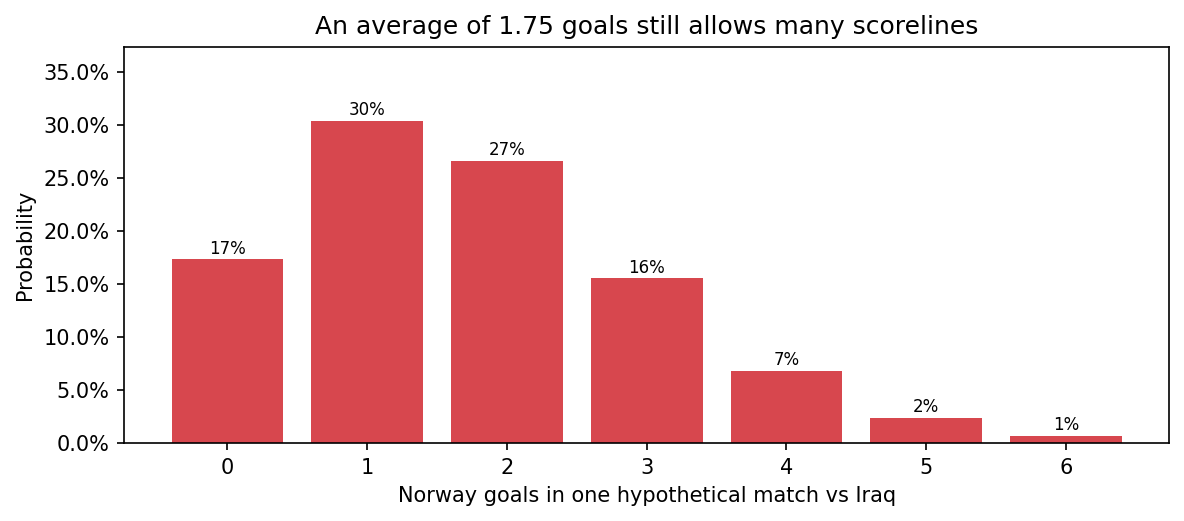

In [16]:
demo_lambda=mu*strength.loc['Norway','attack']*strength.loc['Iraq','defense']
k=np.arange(0,7)
fig,ax=plt.subplots(figsize=(8,3.6))
ax.bar(k,poisson.pmf(k,demo_lambda),color='#d7474e')
ax.set(xticks=k,xlabel='Norway goals in one hypothetical match vs Iraq',ylabel='Probability',
       title=f'An average of {demo_lambda:.2f} goals still allows many scorelines')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
for j,prob in zip(k,poisson.pmf(k,demo_lambda)):
 ax.text(j,prob+.005,f'{prob:.0%}',ha='center',fontsize=8)
ax.set_ylim(0,max(poisson.pmf(k,demo_lambda))+.07);plt.tight_layout();plt.show()

          Norway xGoals*  Opponent xGoals*  Norway win   Draw  Opponent win
opponent                                                                   
Iraq               1.753             0.972       0.558  0.235         0.208
Senegal            1.513             1.530       0.376  0.241         0.383
France             1.733             1.401       0.454  0.234         0.312
Brazil             1.871             1.414       0.483  0.225         0.292
England            1.413             1.417       0.373  0.251         0.375

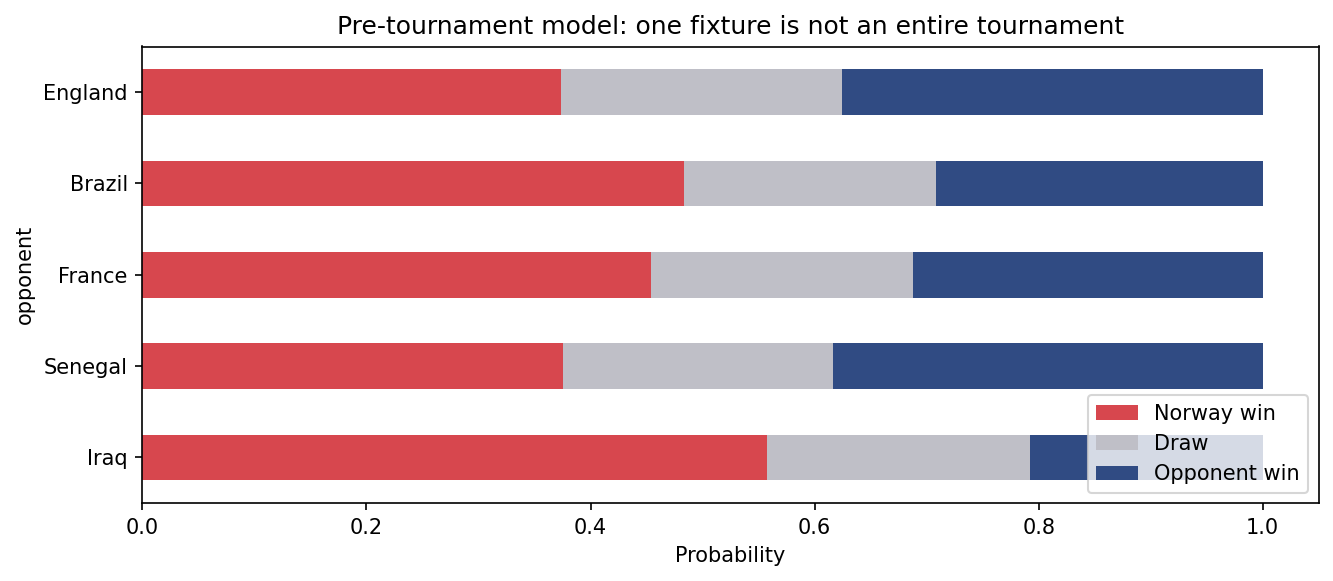

In [17]:
def forecast(opponent, table=strength, mean=mu):
    lam_n = mean*table.loc['Norway','attack']*table.loc[opponent,'defense']
    lam_o = mean*table.loc[opponent,'attack']*table.loc['Norway','defense']
    # 0..25 goals makes omitted Poisson tail negligible for realistic rates.
    goals=np.arange(26)
    grid=np.outer(poisson.pmf(goals,lam_n),poisson.pmf(goals,lam_o))
    if grid.sum()<0.999999: raise ValueError('Increase the score grid')
    return {'opponent':opponent,'Norway xGoals*':lam_n,'Opponent xGoals*':lam_o,
            'Norway win':np.tril(grid,-1).sum(), 'Draw':np.trace(grid),
            'Opponent win':np.triu(grid,1).sum()}
# Rows are Norway's goals; a lower-triangular score grid means Norway scores more.
assert abs(sum(forecast('France')[k] for k in ['Norway win','Draw','Opponent win'])-1)<1e-6
opponents=['Iraq','Senegal','France','Brazil','England']
preds=pd.DataFrame([forecast(o) for o in opponents]).set_index('opponent')
display(preds.round(3))
ax=preds[['Norway win','Draw','Opponent win']].plot.barh(stacked=True,figsize=(9,4),color=['#d7474e','#bfbfc7','#304b83'])
ax.set(xlabel='Probability',title='Pre-tournament model: one fixture is not an entire tournament')
ax.legend(loc='lower right');plt.tight_layout();plt.show()

**Reading the probability chart.** Every row represents one fixture and sums to 100%, allowing for rounding. A 48% Norway-win estimate against Brazil leaves approximately 52% for a draw or Brazil win. It describes a *single neutral match*, not the chance of reaching a knockout round or winning the title. The surprisingly high estimates against Brazil and France require scrutiny because opponent networks, home effects, and omitted context may bias this simple model.

The `xGoals*` column means **expected goals from past score rates**. It is not shot-by-shot xG, which uses shot location and other chance characteristics. Brazil and England are hypothetical pairings at the June 10 cutoff; their later positions in Norway's actual bracket were unknown. These rows assess one-match competitiveness and must not be interpreted as a pre-tournament prediction of the bracket.

## 5. Compare a different quantity: outright market odds

A [June 11, 2026 betting preview](https://sports.yahoo.com/articles/norway-world-cup-2026-odds-132000107.html) quotes Norway at **30/1 to win the title**, **ninth among 48 teams**. Its timing is before Norway's June 16 opener but around the tournament opening, so it is a contemporary external benchmark rather than a guaranteed June 10 price. A sportsbook quote is not a recorded exchange trade or a measure of all public beliefs.

Fractional odds of 30/1 correspond to a raw reciprocal of `1/(30+1)≈3.23%`. This is **not a fair probability** without the full same-book odds board to account for bookmaker margin. The rank suggests Norway was already treated as a relatively serious contender. A title price cannot be numerically compared with a single-match win probability because the events are different.

In [20]:
fractional_a,fractional_b=30,1
raw_implied=fractional_b/(fractional_a+fractional_b)
print(f'30/1 outright → raw implied {raw_implied:.2%}; quoted ninth among 48 teams.')
print('This price asks whether Norway wins the whole tournament, not whether it beats Brazil once.')

30/1 outright → raw implied 3.23%; quoted ninth among 48 teams.
This price asks whether Norway wins the whole tournament, not whether it beats Brazil once.


### Interpreting ninth place and 30/1 together

At 30/1, a successful $1 stake returns $31 including the stake. Its raw implied title chance is about 3.2%, before accounting for bookmaker margin. This can coexist with a ninth-place rank: even a strong country must survive several uncertain matches to win the tournament. The quote provides evidence about relative market attention, not a calibration test of the match model.

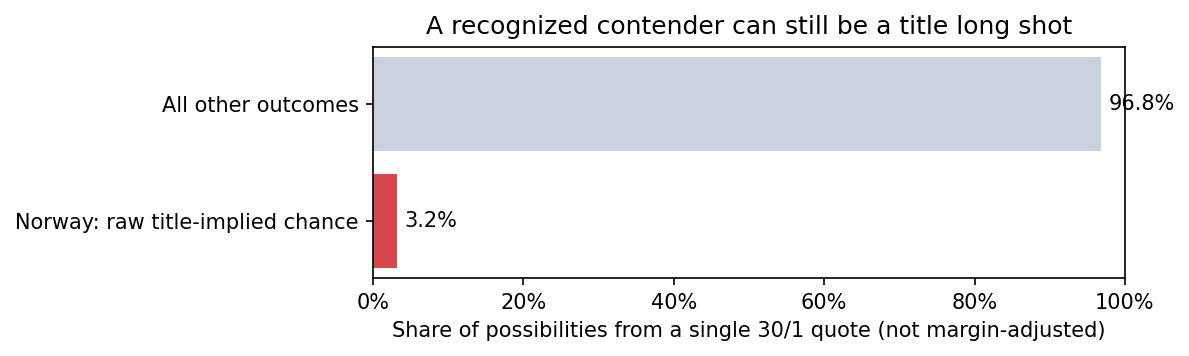

In [22]:
fig,ax=plt.subplots(figsize=(8,2.5))
ax.barh(['Norway: raw title-implied chance','All other outcomes'],[raw_implied,1-raw_implied],
        color=['#d7474e','#cbd2df'])
ax.set_xlim(0,1);ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
for j,v in enumerate([raw_implied,1-raw_implied]): ax.text(v+.01,j,f'{v:.1%}',va='center')
ax.set(xlabel='Share of possibilities from a single 30/1 quote (not margin-adjusted)',
       title='A recognized contender can still be a title long shot')
plt.tight_layout();plt.show()

## 6. Test sensitivity to two modeling choices

**Why this check?** Recency and friendly weights were chosen for interpretability, not tuned on an independent validation set. A conclusion that changes sharply when those weights change is less secure. The next table varies the half-life across 180, 365, and 730 days and the friendly weight across 25%, 50%, and 100%, keeping the same cutoff and model structure. Brazil is a hypothetical June 10 matchup in every scenario, not a model refit after its actual result. The nine numbers are *scenario estimates*, not a confidence interval.

In [24]:
cases=[]
for half_life in [180,365,730]:
 for friendly_weight in [0.25,0.5,1.0]:
  tab, avg=estimate(half_life,friendly_weight)
  p=forecast('Brazil',tab,avg)
  cases.append({'half-life days':half_life,'friendly weight':friendly_weight,
                'Norway attack':tab.loc['Norway','attack'],'Norway defense':tab.loc['Norway','defense'],
                'P(Norway beats Brazil)':p['Norway win']})
sensitivity=pd.DataFrame(cases)
display(sensitivity.round(3))
print('Brazil-win scenario range for Norway:',f"{sensitivity['P(Norway beats Brazil)'].min():.1%}",
      'to',f"{sensitivity['P(Norway beats Brazil)'].max():.1%}")

Brazil-win scenario range for Norway: 39.3% to 53.2%


   half-life days  friendly weight  ...  Norway defense  P(Norway beats Brazil)
0             180             0.25  ...           0.797                   0.532
1             180             0.50  ...           0.764                   0.487
2             180             1.00  ...           0.711                   0.428
3             365             0.25  ...           0.740                   0.532
4             365             0.50  ...           0.709                   0.483
5             365             1.00  ...           0.660                   0.421
6             730             0.25  ...           0.717                   0.499
7             730             0.50  ...           0.688                   0.452
8             730             1.00  ...           0.641                   0.393

[9 rows x 5 columns]

**Sensitivity result.** Norway's estimated one-match win probability against Brazil ranges from about 39% to 53% across these nine settings. The range reflects stated modeling decisions; it is not a sampling-based uncertainty interval. The material change limits how confidently the default 48% can be interpreted.

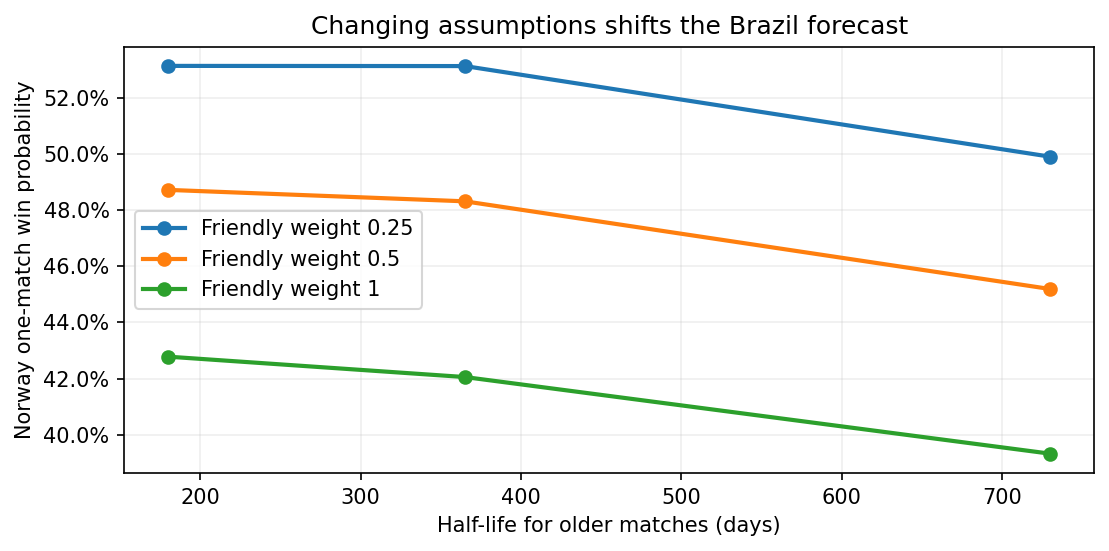

In [26]:
pivot=sensitivity.pivot(index='half-life days',columns='friendly weight',values='P(Norway beats Brazil)')
fig,ax=plt.subplots(figsize=(7.5,3.8))
for col in pivot: ax.plot(pivot.index,pivot[col],marker='o',lw=2,label=f'Friendly weight {col:g}')
ax.set(xlabel='Half-life for older matches (days)',ylabel='Norway one-match win probability',
       title='Changing assumptions shifts the Brazil forecast')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend();ax.grid(alpha=.2);plt.tight_layout();plt.show()

## 7. From a forecast to a hypothetical betting signal

**Why add a market comparison?** Predicting Norway's strength and finding a potentially favorable price are different tasks. A 48% win forecast creates no value if the offered price requires an even higher win probability. For a three-way **90-minute Norway win** market, a draw is a losing bet, even in a knockout game Norway eventually advances from.

For decimal odds `d`, the price's raw break-even probability is `1/d`. If a $100 stake is placed on Norway, its **expected net profit** under model probability `p` is:

`EV($100) = p × $100 × (d − 1) − (1 − p) × $100 = $100 × (p × d − 1)`.

A positive EV is a **model-implied betting signal**, not a guarantee of profit. It assumes the model probability is well calibrated, the quoted price could be obtained, and fees or other costs are negligible. Bookmaker margin is already reflected in the offered price for this specific bet; it cannot be removed merely by looking at one quoted side.

### A fixed exploratory rule

Conditional on Norway reaching the knockout stage, consider **every Norway knockout fixture** with a documented opening price for the same 90-minute win contract. Keep the model fitted on matches through June 9. Place a separate **$100 hypothetical stake** when `model p − 1/d > 0.05` (more than five percentage points of edge); otherwise abstain. The 5-point buffer is an illustrative guard against small estimation errors, not an optimized threshold. The rule and scope are stated before viewing the settlement table, but they were formulated *after* the tournament in this retrospective study; the exercise is not a genuinely pre-registered trading test.

The three prices below are from dated [DraftKings Network](https://dknetwork.draftkings.com/) opening-odds articles: [Ivory Coast +105 on June 27](https://dknetwork.draftkings.com/2026/06/27/opening-odds-for-ivory-coast-vs-norway-in-the-fifa-2026-world-cup/), [Brazil +310 on June 30](https://dknetwork.draftkings.com/2026/06/30/world-cup-2026-brazil-vs-norway-odds/), and [England +280, article updated July 6](https://dknetwork.draftkings.com/2026/07/05/world-cup-2026-norway-vs-england-opening-odds/). They describe 90-minute outcomes, not “to advance.” They are publicly reported indicative prices rather than an executable, timestamped account history.

In [28]:
opening_quotes = pd.DataFrame([
    {'opponent':'Ivory Coast','american':105,'decimal':2.05,'quote_date':'2026-06-27'},
    {'opponent':'Brazil','american':310,'decimal':4.10,'quote_date':'2026-06-30'},
    {'opponent':'England','american':280,'decimal':3.80,'quote_date':'2026-07-06'},
])
assert (pd.to_datetime(opening_quotes.quote_date) < pd.to_datetime(opening_quotes.opponent.map({'Ivory Coast':'2026-06-30','Brazil':'2026-07-05','England':'2026-07-11'}))).all()
opening_quotes['model_p'] = opening_quotes.opponent.map(lambda team: forecast(team)['Norway win'])
opening_quotes['raw_break_even_p'] = 1/opening_quotes.decimal
opening_quotes['edge'] = opening_quotes.model_p - opening_quotes.raw_break_even_p
opening_quotes['expected_net_per_100'] = 100*(opening_quotes.model_p*opening_quotes.decimal-1)
opening_quotes['stake'] = np.where(opening_quotes.edge > .05,100,0)
display(opening_quotes[['opponent','quote_date','american','model_p','raw_break_even_p','edge','expected_net_per_100','stake']].round(3))
print('The rule would select',int((opening_quotes.stake>0).sum()),'of three knockout fixtures; expected net is not realized profit.')

The rule would select 2 of three knockout fixtures; expected net is not realized profit.


      opponent  quote_date  american  ...   edge  expected_net_per_100  stake
0  Ivory Coast  2026-06-27       105  ... -0.057               -11.753      0
1       Brazil  2026-06-30       310  ...  0.239                98.134    100
2      England  2026-07-06       280  ...  0.110                41.902    100

[3 rows x 8 columns]

**Worked Brazil comparison.** At +310, a $100 winning bet profits $310 and a losing bet loses $100. The raw break-even chance is `1/4.10 ≈ 24.4%`. The frozen model assigns roughly **48.3%**, so its estimated edge is about **23.9 percentage points** and expected net profit about **$98 per $100 staked**. Such a large gap is as much a reason to question model calibration as it is a signal under the formula. The market price was posted June 30, after Norway's first four World Cup matches; the model still excludes them. This is a pre-*Brazil-match* decision, not a bet that could be placed on the Brazil pairing before the tournament bracket was known.

**Further limitations.** One upset cannot validate the default estimate or the sensitivity range. The model omits injuries, lineups, travel, tactics, venue effects, shared influences on the teams' goal counts, extra time, and shootouts. Cross-confederation schedules may distort strength comparisons. An actual title forecast would also require group standings, the best-third-place rules, the knockout bracket, and repeated tournament simulations. None of the one-match numbers estimates the title chance.

## 8. Reveal held-out World Cup outcomes

The six Norway World Cup matches are displayed only after the pre-cutoff estimates. This separation tests the narrative without allowing the observed run to determine parameters. The dataset's knockout score can include extra time and excludes penalty shootouts; the simplified model does not distinguish those mechanisms. FIFA records a [2–1 win over Brazil](https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/knockout-stage-match-schedule-bracket) and a quarter-final appearance.

In [31]:
reveal=raw[(raw.date>=CUTOFF)&(raw.tournament=='FIFA World Cup')&
           ((raw.home_team=='Norway')|(raw.away_team=='Norway'))].copy()
reveal['opponent']=np.where(reveal.home_team=='Norway',reveal.away_team,reveal.home_team)
reveal['Norway goals']=np.where(reveal.home_team=='Norway',reveal.home_score,reveal.away_score).astype(int)
reveal['Opponent goals']=np.where(reveal.home_team=='Norway',reveal.away_score,reveal.home_score).astype(int)
reveal['pre-tournament Norway-win probability']=reveal.opponent.map(
    {o:forecast(o)['Norway win'] for o in reveal.opponent.unique()})
display(reveal[['date','opponent','Norway goals','Opponent goals','pre-tournament Norway-win probability']].round(3))

           date  ... pre-tournament Norway-win probability
2569 2026-06-16  ...                                 0.558
2593 2026-06-22  ...                                 0.376
2616 2026-06-26  ...                                 0.454
2628 2026-06-30  ...                                 0.430
2642 2026-07-05  ...                                 0.483
2650 2026-07-11  ...                                 0.373

[6 rows x 5 columns]

### A forecast beside one realized outcome

Each red bar shows the *same pre-tournament model's* Norway-win probability for that opponent. The diamond marks whether Norway actually won. This graphic does not show that a bar “failed” whenever it differs from the 0-or-1 outcome: a probabilistic forecast needs many comparable cases for assessment. **Calibration** would ask whether events assigned about 40% occur in about 40% of a large set; six selected Norway games cannot answer that question.

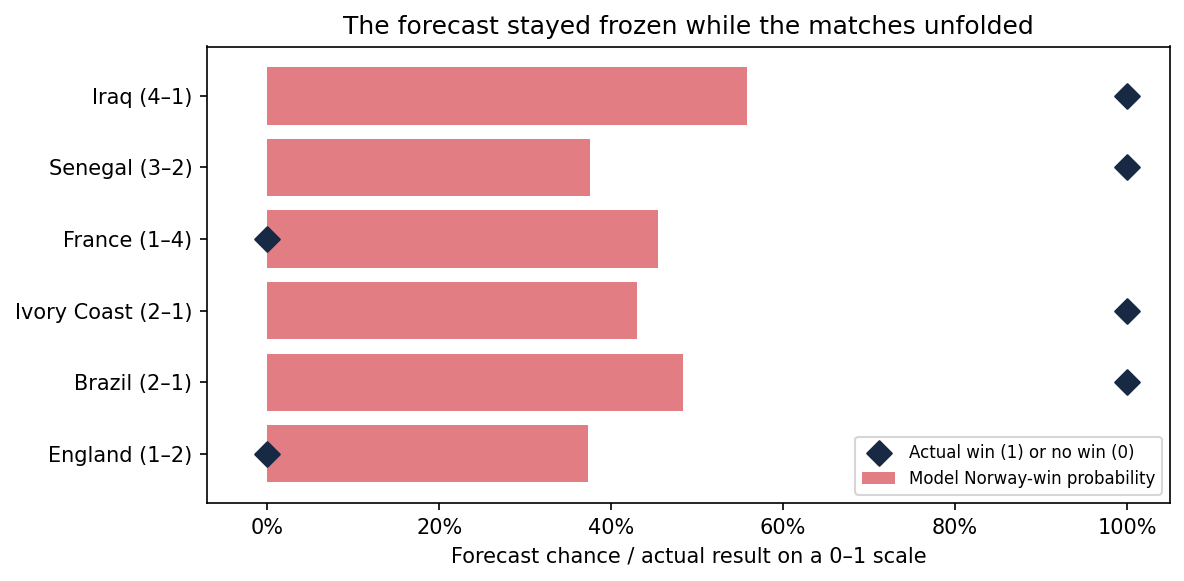

In [33]:
ordered=reveal.sort_values('date').copy()
p=ordered['pre-tournament Norway-win probability'].to_numpy()
won=(ordered['Norway goals']>ordered['Opponent goals']).to_numpy()
fig,ax=plt.subplots(figsize=(8,4))
y=np.arange(len(ordered))
ax.barh(y,p,color='#d7474e',alpha=.7,label='Model Norway-win probability')
ax.scatter(won.astype(float),y,color='#172943',marker='D',s=70,label='Actual win (1) or no win (0)',zorder=5)
ax.set_yticks(y,[f"{o} ({int(g)}–{int(a)})" for o,g,a in zip(ordered.opponent,ordered['Norway goals'],ordered['Opponent goals'])])
ax.invert_yaxis();ax.set_xlim(-.07,1.05)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set(xlabel='Forecast chance / actual result on a 0–1 scale',title='The forecast stayed frozen while the matches unfolded')
ax.legend(loc='lower right',fontsize=8);plt.tight_layout();plt.show()

### Settlement of the fixed $100 knockout-only example

Norway beat Ivory Coast and Brazil in regulation. England–Norway was **1–1 after 90 minutes**, before England won 2–1 in extra time ([England Football match centre](https://www.englandfootball.com/england/mens-senior-team/fixtures-results/2025-26/world-cup/norway-england-fifa-world-cup-quarter-final-saturday-11-july-2026-match-centre)). A 90-minute Norway-win bet on England therefore loses. The settlement below uses 90-minute outcomes and includes the no-bet Ivory Coast row so the selected universe is visible.

In [35]:
settlement = opening_quotes.copy()
settlement['norway_won_90'] = settlement.opponent.map({'Ivory Coast':True,'Brazil':True,'England':False})
settlement['realized_net'] = np.where(settlement.stake.eq(0),0,
    np.where(settlement.norway_won_90,settlement.stake*(settlement.decimal-1),-settlement.stake))
display(settlement[['opponent','model_p','raw_break_even_p','edge','stake','norway_won_90','realized_net']].round(3))
spent=settlement.stake.sum();net=settlement.realized_net.sum()
print(f'Hypothetical staked: ${spent:,.0f}; realized net: ${net:,.0f}; return on stakes: {net/spent:.0%}.')
assert spent==200 and np.isclose(net,210)


Hypothetical staked: $200; realized net: $210; return on stakes: 105%.


      opponent  model_p  raw_break_even_p  ...  stake  norway_won_90  realized_net
0  Ivory Coast    0.430             0.488  ...      0           True           0.0
1       Brazil    0.483             0.244  ...    100           True         310.0
2      England    0.373             0.263  ...    100          False        -100.0

[3 rows x 7 columns]

**What the $210 net does—and does not—show.** It is the mechanical settlement of two selected $100 stakes at quoted opening prices: +$310 for Brazil, −$100 for England. It is **not evidence of a profitable strategy**. This tiny, selected three-match universe was constructed retrospectively; the chosen threshold and model are uncalibrated, price availability is not documented at the level of an actual account, and a different run of matches could lose money despite positive model EV. A defensible profitability claim would require a rule frozen before any results, a complete time-stamped odds archive, consistent market and settlement definitions, and evaluation across many bets. The group-stage matches are outside this explicitly bounded knockout example; no tournament-wide return is claimed.

## 9. Methodology audit: what could change the answer?

| Choice or assumption | Rationale | Limitation | Next check |
|---|---|---|---|
| Matches from January 2024 through June 9, 2026 | Reflects a fairly current squad | A longer history or recent roster change may tell another story | Try a shorter and longer window |
| Old games fade; friendlies count half | Competitive form may matter more | Friendlies can be valuable; the weighting is subjective | Nine-scenario sensitivity analysis above |
| Each opponent changes the expected goal rate | A goal against Italy differs from a goal against Moldova | Different confederations rarely meet, so strength comparisons can drift | Backtest on older intercontinental fixtures |
| Six average-strength pseudo-matches | Stabilizes teams with sparse records | Shrinkage may mute a genuinely strong team | Vary the pseudo-match count |
| Two independent Poisson goal counts | Gives a readable route from expected goals to win/draw/loss | Goals can be correlated; tactics, extra time and penalties complicate results | Compare with a calibrated match model |
| No lineups, xG, injuries, travel or venue effects | These data are hard to reconstruct consistently | Missing information might explain a particular match | Add only documented pre-match inputs |
| June 11 30/1 market quote | Gives a contemporary benchmark | Posted around tournament opening; margin and timestamp matter | Archive a full pre-kickoff odds board |
| Six observed Norway games | Tells the case-study story | Too few for a reliable calibration claim | Score many pre-tournament forecasts |

**Answer to the methodology question.** Norway’s strong qualifying form and the dated ninth-place market ranking survive the basic narrative check. The simple match model suggests they could compete against elite sides, but its Brazil estimate moves from roughly 39% to 53% under modest weighting changes. Under the stated qualitative definition, the evidence supports *recognized dark horse*. It does not prove market undervaluation or model calibration.

**Methodological priority.** A historical, time-ordered backtest on international fixtures would test calibration and reveal whether cross-confederation matches or alternative prior strengths systematically change the estimates. That check is more important than tuning weights to fit Norway’s known result.

### What this changes about the story

**“Underdog” is a question about the reference point.** Norway could be overlooked by reputation shaped by its long World Cup absence, respected by the market as a top-ten title contender, and still have only a small chance of winning the title. The simplified performance model even rated Norway competitive in individual fixtures with elite teams. Its high estimates and the sensitivity chart are reasons to ask how well the model travels across uneven international schedules.

**Why this matters beyond soccer:** headlines tend to call an upset “unpredictable” after it happens. A forecast asks what chance was assigned *before* it happened and whether that chance was reasonable. Forecasts should be assessed by how well their probabilities represent uncertainty across many events.

### Conclusion

The evidence supports a **qualified** answer. Norway was a long shot to win the title. Its emphatic qualifying run was a strong pre-tournament signal, and a reported **ninth-place outright market rank** suggests the betting market already viewed it as a serious second-tier contender. Norway’s quarter-final and Brazil victory are compatible with that prior belief; one result cannot establish that the market was mispriced. The simple model actually rates Norway roughly even with or ahead of Brazil and France in one-off neutral fixtures; that uncalibrated result is a hypothesis to test, not a trustworthy betting edge. It can test opponent-specific competitiveness, but this notebook **does not estimate Norway’s probability of reaching the quarter-finals or prove market efficiency**.

A stronger claim would require an archived pre-kickoff odds board with timestamps, a same-book margin adjustment, a calibrated model simulating the 48-team tournament, and backtests over many matches or tournaments. Comparable events must be compared: title probability to title odds, for example.

The knockout-only $100-stake illustration yields +$210 in this three-match sample, but its retrospective design cannot establish a durable betting edge.

### Source notes and audit trail

1. Course lecture: *7. Prediction Market Soccer 1-2*, sections “Poisson and Dixon-Coles Models” and “W-5.” Attack and defense interact to set per-match scoring rates; retrospective scoring requires temporal separation. The lecture’s Spain–Cabo Verde worked example is not training data.
2. [Mart Jürisoo, international results CSV](https://github.com/martj42/international_results), CC0; local snapshot downloaded **2026-09-28** and bundled with the notebook. Check his [data dictionary](https://github.com/martj42/international_results#content). Date filtering happens before any parameter fitting.
3. [FIFA on Norway’s qualifying performance](https://www.fifa.com/it/tournaments/mens/worldcup/canadamexicousa2026/articles/erling-haaland-statistiche-dichiarazioni-record): eight wins, 37 for, five against (published before the tournament).
4. [June 11 Norway outright market preview](https://sports.yahoo.com/articles/norway-world-cup-2026-odds-132000107.html): quoted 30/1 and ninth. Publication date and price timing limit the claim; no claim of June 10 price history.
5. [DraftKings Network knockout opening odds](https://dknetwork.draftkings.com/2026/06/30/world-cup-2026-brazil-vs-norway-odds/), with the individual Côte d’Ivoire and England links in Section 7, for 90-minute prices.
6. [England Football match centre](https://www.englandfootball.com/england/mens-senior-team/fixtures-results/2025-26/world-cup/norway-england-fifa-world-cup-quarter-final-saturday-11-july-2026-match-centre): 1–1 after 90 minutes.
7. [FIFA official knockout bracket](https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/knockout-stage-match-schedule-bracket): held-out outcome verification.

**AI assistance disclosure.** As encouraged by the course, an AI assistant helped research sources, structure this notebook, write and check code, and draft explanations. 